# ============================================================
# 3_analise.ipynb
# Fase 3 do pipeline: Camada Gold
# Perguntas de negócio + gráficos + tabela e view agregadas
# ============================================================

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
from config import MYSQL_CONFIG


In [8]:
# Configurações de visualização

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

In [9]:
# Conexão com o banco via SQLAlchemy
usuario  = MYSQL_CONFIG["user"]
senha    = quote_plus(MYSQL_CONFIG["password"])
host     = MYSQL_CONFIG["host"]
porta    = MYSQL_CONFIG["port"]
database = MYSQL_CONFIG["database"]

engine = create_engine(
    f"mysql+mysqlconnector://{usuario}:{senha}@{host}:{porta}/{database}"
)

print("Conexão estabelecida com sucesso!")

Conexão estabelecida com sucesso!


In [10]:
# ============================================================
# PERGUNTA 1: Os 5 órgãos com maior custo total?
# ============================================================

query_p1 = """
    SELECT
        nome_orgao_superior,
        ROUND(SUM(valor_total), 2) AS custo_total
    FROM silver_viagem
    WHERE valor_total IS NOT NULL
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
    LIMIT 5
"""

df_p1 = pd.read_sql(query_p1, engine)
print(df_p1.to_string(index=False))

                           nome_orgao_superior  custo_total
     Ministério da Justiça e Segurança Pública 486933121.65
                          Ministério da Defesa 156070304.49
                        Ministério da Educação 111291349.34
Ministério do Meio Ambiente e Mudança do Clima  49697710.16
              Ministério da Previdência Social  40417309.06


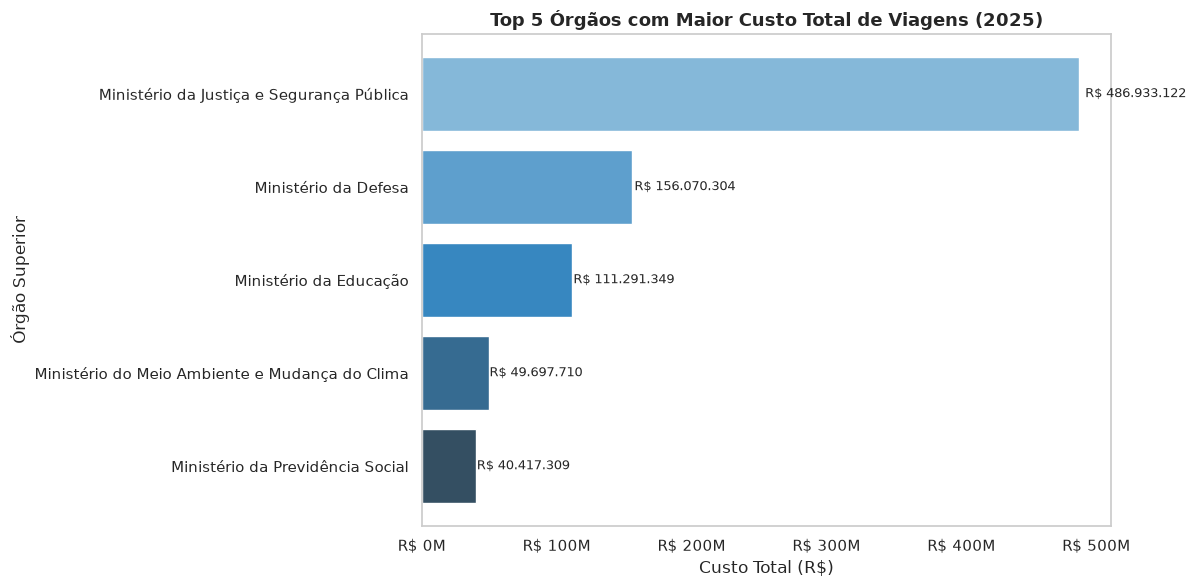

In [13]:
# Gráfico P1 — 5 órgãos com maior custo total
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    df_p1["nome_orgao_superior"],
    df_p1["custo_total"],
    color=sns.color_palette("Blues_d", len(df_p1))
)

# Inverte para o maior ficar no topo
ax.invert_yaxis()

# Rótulos de valor no final de cada barra
for bar in bars:
    valor = bar.get_width()
    ax.text(
        valor * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f"R$ {valor:,.0f}".replace(",", "."),
        va="center", fontsize=9
    )

# Formata eixo X em milhões
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x/1e6:.0f}M")
)

ax.set_title("Top 5 Órgãos com Maior Custo Total de Viagens (2025)", fontsize=13, fontweight="bold")
ax.set_xlabel("Custo Total (R$)")
ax.set_ylabel("Órgão Superior")

ax.grid(False)
plt.tight_layout()
plt.savefig("images/grafico_p1_orgaos.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# ============================================================
# PERGUNTA 2: Os 3 destinos com maior custo médio por viagem?
# ============================================================

query_p2 = """
    SELECT
        t.destino_cidade,
        t.destino_uf,
        COUNT(DISTINCT t.id_viagem)         AS total_viagens,
        ROUND(AVG(v.valor_total), 2)        AS custo_medio
    FROM silver_trecho t
    JOIN silver_viagem v ON t.id_viagem = v.id_viagem
    WHERE v.valor_total IS NOT NULL
        AND t.destino_cidade IS NOT NULL
        AND t.destino_cidade != ''
    GROUP BY t.destino_cidade, t.destino_uf
    ORDER BY custo_medio DESC
    LIMIT 3
"""

df_p2 = pd.read_sql(query_p2, engine)
print(df_p2.to_string(index=False))

destino_cidade destino_uf  total_viagens  custo_medio
        Tejupá  São Paulo              1    115175.00
     Chavantes  São Paulo              1    114557.01
     Teolândia      Bahia              1    109322.50


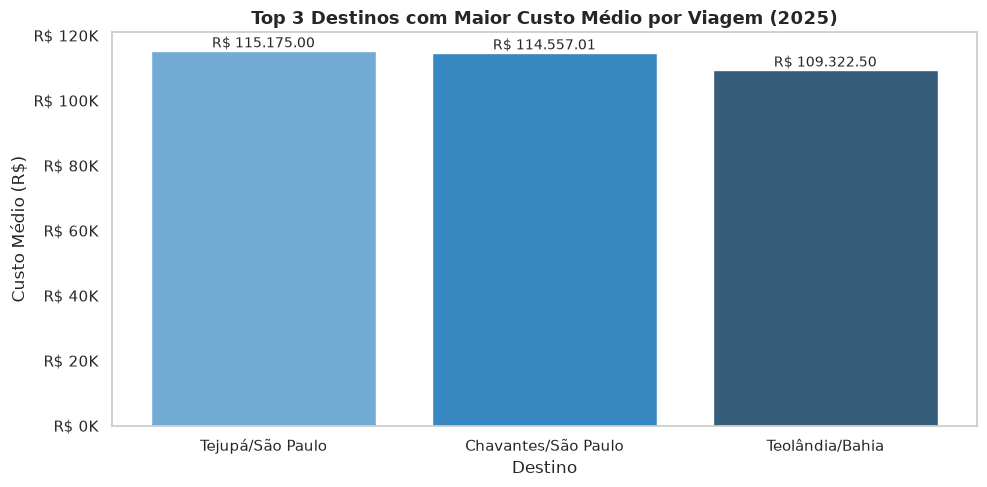

In [21]:
# Gráfico P2 — 3 destinos com maior custo médio
fig, ax = plt.subplots(figsize=(10, 5))

labels = df_p2["destino_cidade"] + "/" + df_p2["destino_uf"]

bars = ax.bar(
    labels,
    df_p2["custo_medio"],
    color=sns.color_palette("Blues_d", len(df_p2))
)

# Rótulos de valor no topo de cada barra
for bar in bars:
    valor = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        valor * 1.01,
        f"R$ {valor:,.2f}".replace(",", "."),
        ha="center", fontsize=10
    )

ax.set_title("Top 3 Destinos com Maior Custo Médio por Viagem (2025)", fontsize=13, fontweight="bold")
ax.set_xlabel("Destino")
ax.set_ylabel("Custo Médio (R$)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x/1e3:.0f}K")
)
ax.grid(False)

plt.tight_layout()
plt.savefig("images/grafico_p2_destinos.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
#============================================================
# PERGUNTA 3: A viagem de maior duração e seu custo total? 
#============================================================

query_p3 = """
SELECT
    v.id_viagem,
    v.nome_viajante,
    v.nome_orgao_superior,
    v.destinos,
    v.data_inicio,
    v.data_fim,
    v.duracao_dias,
    v.valor_total
FROM silver_viagem v
WHERE v.duracao_dias IS NOT NULL
ORDER BY v.duracao_dias DESC
LIMIT 1
"""

df_p3 = pd.read_sql(query_p3, engine)
print(df_p3.to_string(index=False))

          id_viagem                     nome_viajante              nome_orgao_superior      destinos data_inicio   data_fim  duracao_dias  valor_total
0000000000020699856 LUISANGELA CORREA FRANCO DE FARIA Ministério da Previdência Social Mogi Mirim/SP  2025-01-13 2026-01-31           383          0.0


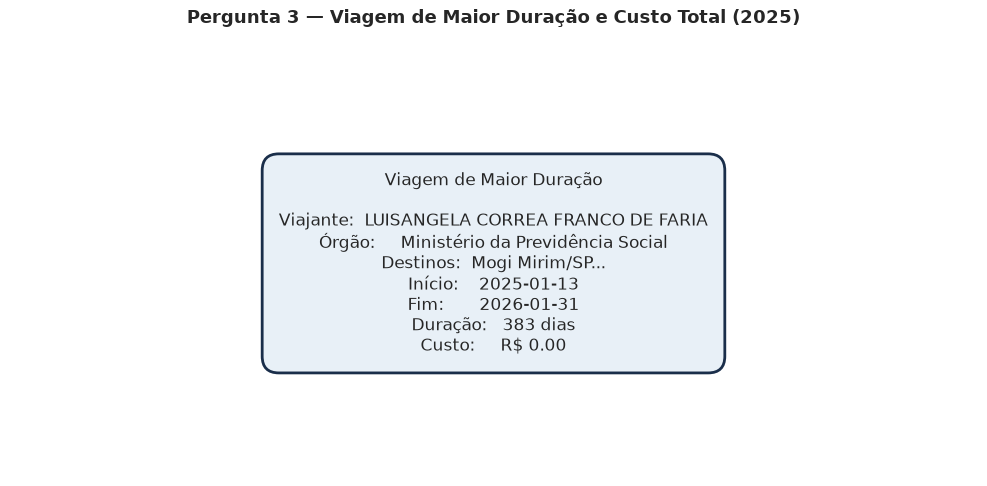

In [ ]:
# Gráfico P3 — Viagem de maior duração - Demosntração em forma de Card
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

# Pega os valores do dataframe
row = df_p3.iloc[0]

texto = (
    f"Viagem de Maior Duração\n\n"
    f"Viajante:  {row['nome_viajante']}\n"
    f"Órgão:     {row['nome_orgao_superior']}\n"
    f"Destinos:  {str(row['destinos'])[:80]}...\n"
    f"Início:    {row['data_inicio']}\n"
    f"Fim:       {row['data_fim']}\n"
    f"Duração:   {row['duracao_dias']} dias\n"
    f"Custo:     R$ {row['valor_total']:,.2f}".replace(",", ".")
)

ax.text(
    0.5, 0.5, texto,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="center",
    horizontalalignment="center",
    bbox=dict(boxstyle="round,pad=1", facecolor="#e8f0f7", edgecolor="#1a2e4a", linewidth=2)
)

ax.set_title("Viagem de Maior Duração e Custo Total (2025)",
             fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("images/grafico_p3_maior_duracao.png", dpi=150, bbox_inches="tight")
plt.show()

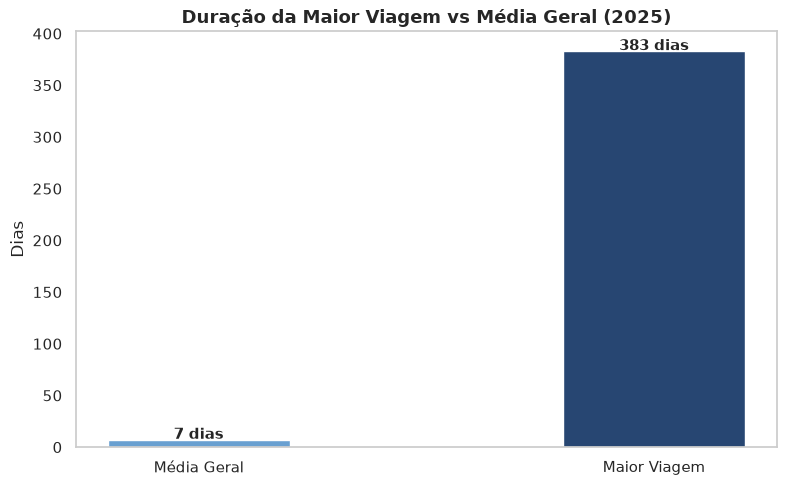

In [ ]:
# Gráfico P3.2 — Viagem de maior duração / média geral
media_duracao = pd.read_sql(
    "SELECT ROUND(AVG(duracao_dias), 1) AS media FROM silver_viagem WHERE duracao_dias IS NOT NULL",
    engine
).iloc[0]["media"]

fig, ax = plt.subplots(figsize=(8, 5))
categorias = ["Média Geral", "Maior Viagem"]
valores = [float(media_duracao), int(df_p3.iloc[0]["duracao_dias"])]
cores = ["#69a0d1", "#274672"]

bars = ax.bar(categorias, valores, color=cores, width=0.4)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.0f} dias",
        ha="center", fontweight="bold"
    )

ax.set_title("Duração da Maior Viagem vs Média Geral (2025)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Dias")
ax.grid(False)
plt.tight_layout()
plt.savefig("images/grafico_p3_maior_duracao.png", dpi=150, bbox_inches="tight")
plt.show()